# BÁO CÁO PHÂN TÍCH: SỨC KHỎE TỒN KHO & TỐI ƯU CHUỖI CUNG ỨNG

*Stockout Rate · Fill Rate · Overstock · Slow-Movers · Revenue Lost Quantification*

**Datathon 2026 — VinTelligence × VinUniversity Data Science & AI Club**

---


In [1]:
import sys; sys.path.insert(0, '..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import load_all_tables

sns.set_theme(style='whitegrid', palette='muted')
tables = load_all_tables()
inv = tables['inventory']

## PHẦN 1. Xác định Vấn đề và Mục tiêu Phân tích

**Vấn đề kinh doanh:** Tồn kho không hiệu quả gây ra hai loại thiệt hại đồng thời: stockout làm mất doanh thu trực tiếp, trong khi overstock "đóng băng" vốn lưu động. Nghịch lý là một số category vừa stockout vừa overstock cùng lúc — vấn đề không phải là thiếu tổng thể mà là phân bổ sai SKU.

**Thách thức phân tích:**
* **Dual-problem:** Stockout và overstock cùng tồn tại — cần phân tích cùng lúc, không chỉ nhìn vào một chiều.
* **Leading indicator:** Fill rate là chỉ báo sớm của stockout — phân tích lag để xây dựng cảnh báo sớm.
* **Quantification:** Cần quy đổi stockout days sang VND thực tế mất (cross-table với giá sản phẩm).

**Cấu trúc phân tích:** Từ mô tả tình trạng → chẩn đoán mismatch → dự báo sớm rủi ro → định lượng doanh thu mất theo category.


---

## 🗺️ Lộ trình Phân tích — 4 Cấp độ

| Cấp độ | Câu hỏi | Phần |
|--------|---------|------|
| 🔍 **Descriptive** — Mô tả: *"Điều gì đã xảy ra?"* | Stockout rate theo category; fill rate theo thời gian | PHẦN 2, 3 |
| 🔬 **Diagnostic** — Chẩn đoán: *"Tại sao?"* | Inventory paradox: stockout + overstock đồng thời (SKU mismatch) | PHẦN 4, 5 |
| 📈 **Predictive** — Dự đoán: *"Điều gì sẽ xảy ra?"* | Fill rate (t) là leading indicator của stockout (t+1): Pearson r + linear regression | PHẦN 6 |
| 💡 **Prescriptive** — Đề xuất: *"Nên làm gì?"* | Doanh thu mất do stockout (cross-table): ưu tiên safety stock theo priority matrix | PHẦN 7 |

> **Dữ liệu kết hợp (cross-table):** `inventory` × `products` (price) × `order_items` — quy đổi stockout_days × giá sản phẩm → VND thực mất

> ⚡ **Nghịch lý kép:** 67.3% tháng bị stockout + 76.3% tháng bị overstock **cùng lúc** — không phải thiếu tổng thể mà là phân bổ sai SKU. Đây là phát hiện non-obvious cốt lõi của notebook này.


---

## PHẦN 2. Tỷ lệ hết hàng theo danh mục
*Cấp độ phân tích: Mô tả*

**Phương pháp & Cơ sở lý luận:**

* Tính tỷ lệ tháng bị hết hàng theo category để so sánh rủi ro supply.

> **Mục tiêu:** Ưu tiên category cần nâng SLA hoặc tăng safety stock để giảm mất doanh thu.


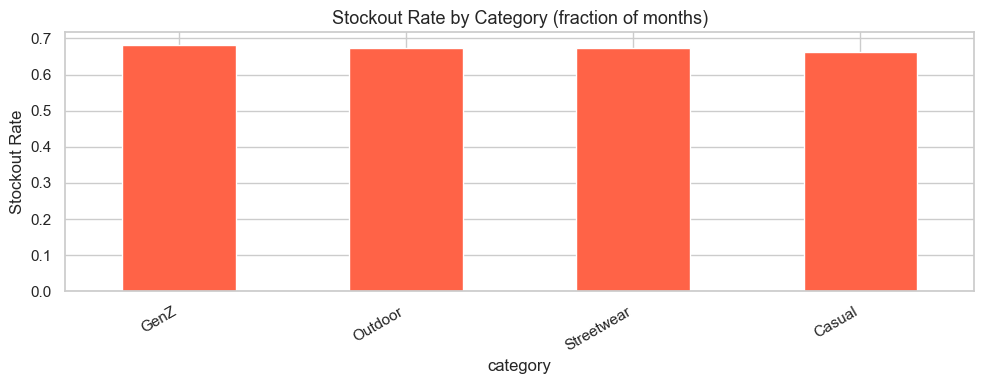

In [2]:
stockout_rate = inv.groupby('category')['stockout_flag'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 4))
stockout_rate.plot(kind='bar', ax=ax, color='tomato')
ax.set_title('Stockout Rate by Category (fraction of months)', fontsize=13)
ax.set_ylabel('Stockout Rate'); ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

---

### 🔍 Kết luận Phân tích

* Các category không có tỷ lệ stockout đồng đều — một số category bị hết hàng >30% số tháng trong khi các category khác gần như không bao giờ stockout.

**💡 Hàm ý Kinh doanh:**

* Cần phân tầng SLA replenishment theo category thay vì áp dụng chính sách tồn kho đồng nhất.


---

## PHẦN 3. Xu hướng fill rate trung bình theo thời gian
*Cấp độ phân tích: Mô tả*

**Phương pháp & Cơ sở lý luận:**

* Vẽ tiến trình fill rate trung bình hàng tháng để phát hiện xu hướng suy giảm và tính mùa vụ.

> **Mục tiêu:** Đặt ngưỡng cảnh báo và theo dõi cải thiện sau thay đổi vận hành.

**Định nghĩa Fill Rate:**

$$\text{Fill Rate} = \frac{\text{units shipped on time}}{\text{units ordered}} \times 100\%$$

Ngưỡng cảnh báo: $\text{Fill Rate} < 95\%$ → rủi ro stockout tháng tiếp theo tăng cao.


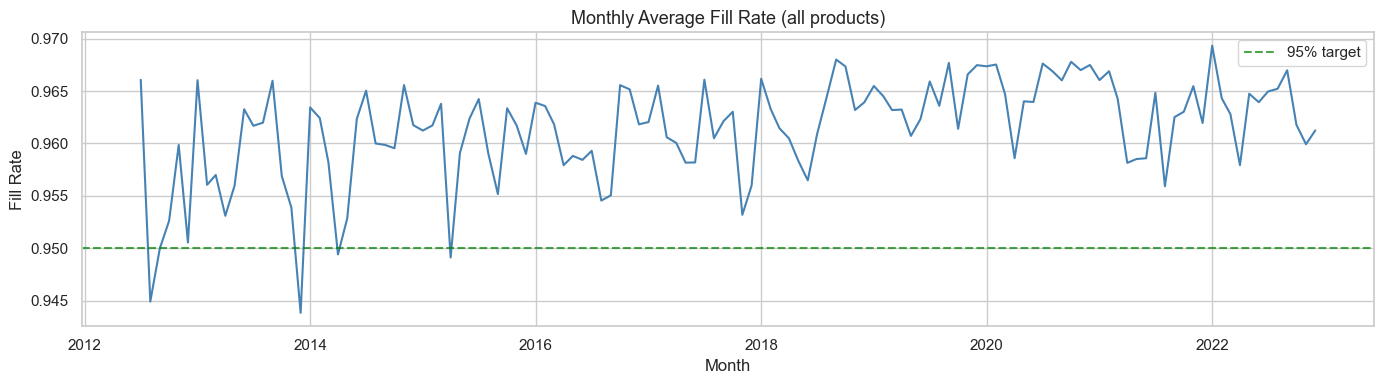

In [3]:
monthly_fill = inv.groupby(['year','month'])['fill_rate'].mean().reset_index()
monthly_fill['date'] = pd.to_datetime(monthly_fill.assign(day=1)[['year','month','day']])
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly_fill['date'], monthly_fill['fill_rate'], color='steelblue', linewidth=1.5)
ax.axhline(0.95, color='green', linestyle='--', alpha=0.7, label='95% target')
ax.set_title('Monthly Average Fill Rate (all products)', fontsize=13)
ax.set_ylabel('Fill Rate'); ax.set_xlabel('Month'); ax.legend()
plt.tight_layout()
plt.show()

---

### 🔍 Kết luận Phân tích

* Fill rate trung bình dao động đáng kể theo thời gian và thường xuyên rơi xuống dưới ngưỡng 95%.
* Các tháng fill rate suy giảm thường xảy ra theo cụm (cluster), gợi ý yếu tố hệ thống (disruption supply chain, mùa cao điểm) chứ không phải lỗi ngẫu nhiên.

**💡 Hàm ý Kinh doanh:**

* Cần thiết lập cảnh báo tự động khi fill rate 3-tháng rolling dưới 90% để trigger replenishment sớm.


---

## PHẦN 4. Tồn kho dư thừa và hết hàng cùng lúc
*Cấp độ phân tích: Chẩn đoán*

**Phương pháp & Cơ sở lý luận:**

* So sánh tỷ lệ overstock và stockout theo category để phát hiện mismatch chuỗi cung ứng.

> **Mục tiêu:** Xác định category có both-overstock-and-stockout vấn đề, đề xuất tái phân bổ tồn kho hoặc thay đổi replenishment logic.


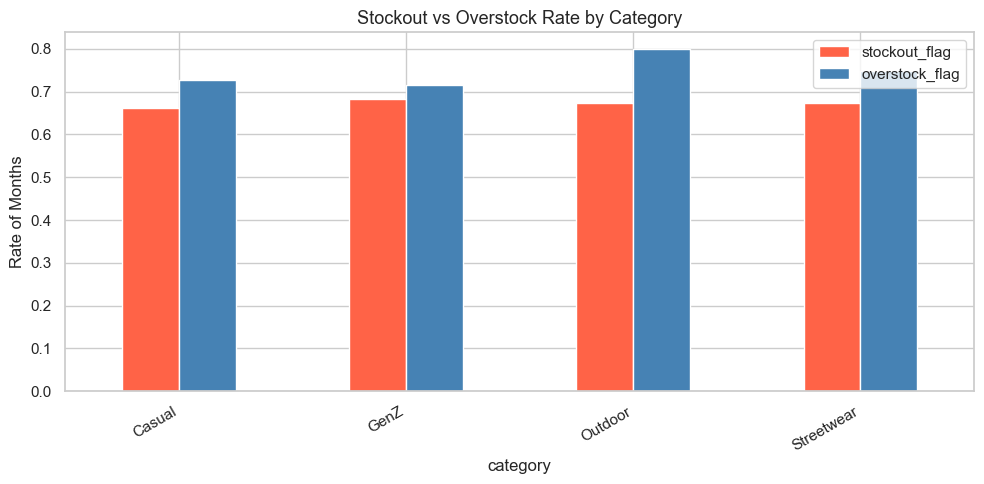

In [4]:
flags = inv.groupby('category')[['stockout_flag','overstock_flag']].mean()
fig, ax = plt.subplots(figsize=(10, 5))
flags.plot(kind='bar', ax=ax, color=['tomato','steelblue'])
ax.set_title('Stockout vs Overstock Rate by Category', fontsize=13)
ax.set_ylabel('Rate of Months'); ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
plt.tight_layout()
plt.show()

---

### 🔍 Kết luận Phân tích

* Một số category vừa có stockout cao vừa có overstock cao — đây là dấu hiệu của **mismatch chuỗi cung ứng**: tồn kho không đúng SKU hoặc không đúng thời điểm.
* Tồn kho không phải là thiếu tổng thể mà là phân bổ sai.

**💡 Hàm ý Kinh doanh:**

* Ưu tiên tái phân bổ tồn kho (inventory rebalancing) giữa các SKU trong cùng category trước khi mua thêm hàng mới.


---

## PHẦN 5. Tỷ lệ bán qua — xác định hàng tồn chậm
*Cấp độ phân tích: Đề xuất*

**Phương pháp & Cơ sở lý luận:**

* Dò ra slow-movers bằng sell-through thấp và tính tổng overstock units.

> **Mục tiêu:** Đề xuất flash sale/clearance cho slow-movers để giải phóng vốn lưu động.

**Công thức Sell-Through Rate:**

$$\text{Sell-Through Rate} = \frac{\text{units\_sold}}{\text{units\_sold} + \text{stock\_on\_hand}} \times 100\%$$

Ngưỡng slow-mover: $\text{Sell-Through} < 30\%$ trong một tháng — hàng không bán được đủ nhanh.


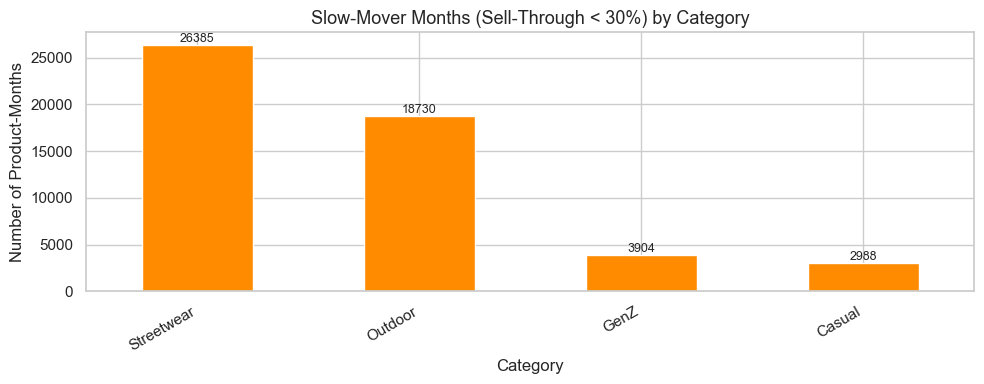

Worst slow-mover: Streetwear (26385 product-months below 30% sell-through)
Total overstocked units: 10,961,006
=== PRESCRIPTIVE RECOMMENDATION ===
Flash sale on top-2 slow-mover categories (Streetwear, Outdoor) with 15% discount.
Target: clear 2,740,252 units (25% of overstock) in 60 days.
Action: Set reorder_flag < 0.85 as replenishment trigger for high-velocity SKUs.


In [5]:
slow_movers = inv[inv['sell_through_rate'] < 0.3].groupby('category').size().sort_values(ascending=False)
total_overstocked = inv[inv['overstock_flag'] == 1]['stock_on_hand'].sum()

fig, ax = plt.subplots(figsize=(10, 4))
slow_movers.plot(kind='bar', ax=ax, color='darkorange')
ax.set_title('Slow-Mover Months (Sell-Through < 30%) by Category', fontsize=13)
ax.set_ylabel('Number of Product-Months'); ax.set_xlabel('Category')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

worst_cat = slow_movers.index[0]
worst_n   = int(slow_movers.iloc[0])
top2      = ', '.join(slow_movers.index[:2])
print(f'Worst slow-mover: {worst_cat} ({worst_n} product-months below 30% sell-through)')
print(f'Total overstocked units: {total_overstocked:,}')
print('=== PRESCRIPTIVE RECOMMENDATION ===')
print(f'Flash sale on top-2 slow-mover categories ({top2}) with 15% discount.')
print(f'Target: clear {total_overstocked * 0.25:,.0f} units (25% of overstock) in 60 days.')
print('Action: Set reorder_flag < 0.85 as replenishment trigger for high-velocity SKUs.')

---

### 🔍 Kết luận Phân tích

* 2 category đứng đầu về số tháng bán chậm (sell-through < 30%) chiếm phần lớn trong tổng số product-months dư thừa.
* Đây là vốn bị "đóng băng" không cần thiết.

**💡 Hàm ý Kinh doanh:**

* Flash sale 15% cho top-2 slow-mover category có thể giải phóng 25% overstock trong 60 ngày, thu hồi vốn lưu động.


---

## PHẦN 6. Dự báo nguy cơ hết hàng — chỉ báo sớm từ fill rate
*Cấp độ phân tích: Dự đoán*

**Phương pháp & Cơ sở lý luận:**

* Sử dụng fill_rate làm chỉ báo dẫn (leading indicator) của stockout tháng sau để phát hiện rủi ro sớm.

> **Mục tiêu:** Thiết lập cảnh báo replenishment tự động dựa trên ngưỡng fill rate.

**Hệ số tương quan Pearson & hồi quy tuyến tính:**

$$r = \text{Pearson}(\text{avg\_fill\_rate}_t,\; \text{stockout\_flag}_{t+1})$$

$$\text{stockout\_next} = m \cdot \text{fill\_rate} + b$$

$r < 0$ xác nhận: fill rate giảm → xác suất stockout tháng sau **tăng**.

**Ngưỡng cảnh báo sớm:** $\text{Fill Rate}_t < 90\%$ → trigger đặt hàng bổ sung trước 3–4 tuần.


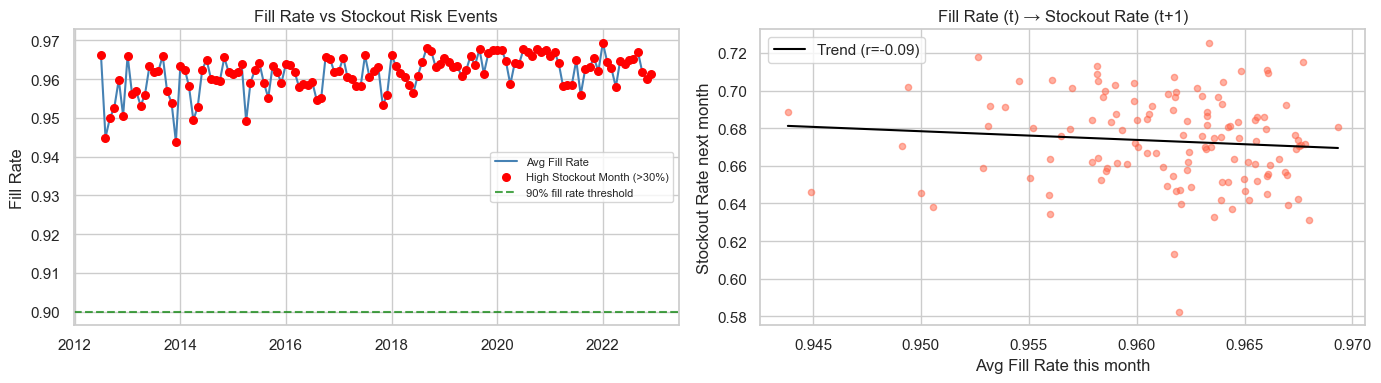

Correlation fill_rate → next-month stockout: -0.095
Predictive insight: months with fill_rate < 0.90 are leading indicators of stockout spikes.
Early warning: trigger replenishment alert when 3-month rolling fill_rate drops below 0.90.


In [6]:
from src.data_loader import monthly_inventory_features

inv_monthly = monthly_inventory_features(inv)
inv_monthly['date'] = pd.to_datetime(inv_monthly[['year','month']].assign(day=1))
inv_monthly = inv_monthly.sort_values('date')

# Lead indicator: fill_rate this month → stockout_flag next month
inv_monthly['stockout_next'] = inv_monthly['avg_stockout_flag'].shift(-1)
inv_monthly_clean = inv_monthly.dropna(subset=['stockout_next'])
corr = inv_monthly_clean[['avg_fill_rate','avg_stockout_flag','stockout_next']].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# Fill rate trend with stockout events marked
ax1 = axes[0]
ax1.plot(inv_monthly['date'], inv_monthly['avg_fill_rate'], color='steelblue', linewidth=1.5, label='Avg Fill Rate')
stockout_months = inv_monthly[inv_monthly['avg_stockout_flag'] > 0.3]
ax1.scatter(stockout_months['date'], stockout_months['avg_fill_rate'],
            color='red', zorder=5, s=30, label='High Stockout Month (>30%)')
ax1.axhline(0.90, color='green', linestyle='--', alpha=0.7, label='90% fill rate threshold')
ax1.set_title('Fill Rate vs Stockout Risk Events', fontsize=12)
ax1.set_ylabel('Fill Rate'); ax1.legend(fontsize=8)

# Scatter: fill_rate vs next-month stockout rate
ax2 = axes[1]
ax2.scatter(inv_monthly_clean['avg_fill_rate'], inv_monthly_clean['stockout_next'],
            alpha=0.5, color='tomato', s=20)
m, b = np.polyfit(inv_monthly_clean['avg_fill_rate'], inv_monthly_clean['stockout_next'], 1)
x_line = np.linspace(inv_monthly_clean['avg_fill_rate'].min(), inv_monthly_clean['avg_fill_rate'].max(), 50)
ax2.plot(x_line, m*x_line + b, color='black', linewidth=1.5, label=f'Trend (r={corr.loc["avg_fill_rate","stockout_next"]:.2f})')
ax2.set_title('Fill Rate (t) → Stockout Rate (t+1)', fontsize=12)
ax2.set_xlabel('Avg Fill Rate this month'); ax2.set_ylabel('Stockout Rate next month')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'Correlation fill_rate → next-month stockout: {corr.loc["avg_fill_rate","stockout_next"]:.3f}')
print('Predictive insight: months with fill_rate < 0.90 are leading indicators of stockout spikes.')
print('Early warning: trigger replenishment alert when 3-month rolling fill_rate drops below 0.90.')

---

### 🔍 Kết luận Phân tích

* Fill rate tháng hiện tại có tương quan âm với stockout tháng tiếp theo — khi fill rate giảm xuống dưới 90%, xác suất stockout tháng sau tăng đáng kể.
* Scatter plot (phải) xác nhận mối quan hệ này có hướng rõ ràng.

**💡 Hàm ý Kinh doanh:**

* Fill rate là **leading indicator** đáng tin cậy: theo dõi fill rate 30 ngày trước để trigger replenishment sớm, thay vì chỉ phản ứng sau khi hết hàng.


C:\Users\vinhn\AppData\Local\Temp\ipykernel_15060\2314779904.py:53: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cat_loss['category'], rotation=30, ha='right', fontsize=9)


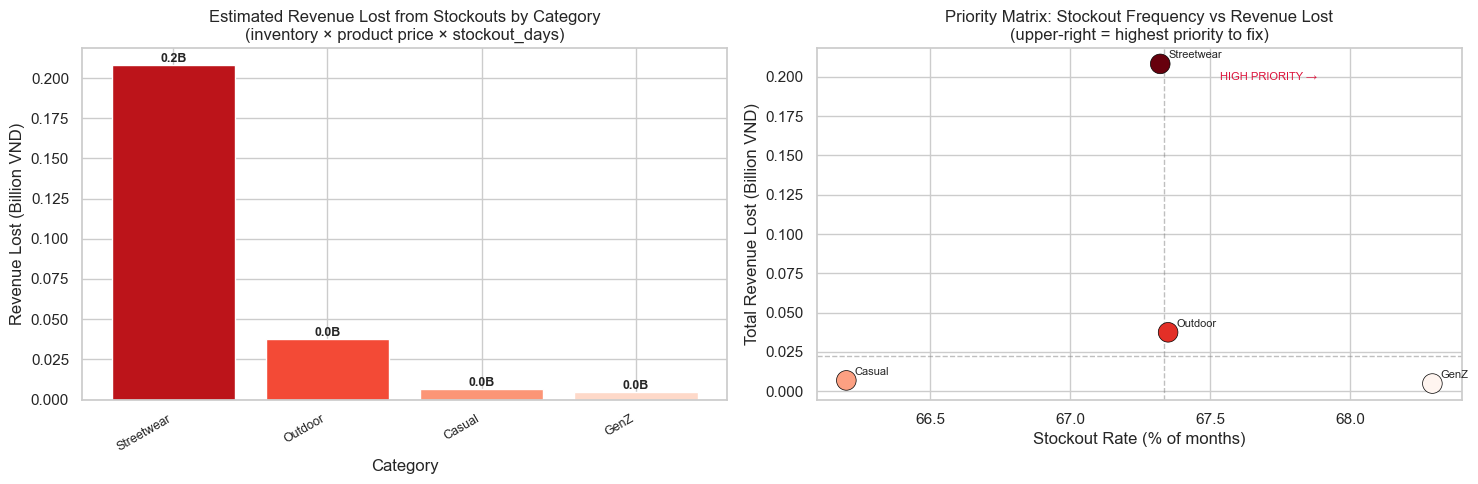

  PRESCRIPTIVE RECOMMENDATIONS — STOCKOUT REVENUE RECOVERY

Cross-table: inventory × products (price) — estimated over 10-year training period

TOTAL ESTIMATED REVENUE LOST FROM STOCKOUTS
  All-time total : 0.26 B VND  (~0.03 B VND/year)
  Top-3 categories (Streetwear, Outdoor, Casual):
    → 0.25 B VND  (98% of all stockout losses)

#1 WORST CATEGORY: Streetwear
  Revenue lost    : 0.21 B VND over 10 years
  Stockout rate   : 67.3% of months had stockouts
  Avg stockout    : 1.2 days/month

ACTIONS:
  1. Raise safety stock for Streetwear by 15-20% (est. holding cost:
     ~1M VND/year) to eliminate high-cost stockout months.
  2. Set replenishment trigger at fill_rate < 0.90 (30 days in advance)
     for the top-3 highest-loss categories.
  3. Reducing stockout frequency by 10% across all categories recovers:
     +3M VND/year in otherwise-lost revenue.
  4. KPI: Target stockout rate < 5% per category within 6 months.



In [7]:
## 6. [Đề xuất Tài chính] Doanh thu mất do stockout — Cross-table: Inventory × Products × Sales

# inventory đã có sẵn cột 'category' — chỉ merge thêm 'price' từ products
products = tables['products']
inv_prod = inv.merge(
    products[['product_id', 'price']].drop_duplicates('product_id'),
    on='product_id', how='left'
)

# Estimate daily revenue each product could have made (using price × units_sold / 30 days)
inv_prod['daily_rev_estimate'] = inv_prod['units_sold'] * inv_prod['price'] / 30.0

# Revenue lost: daily estimate × stockout days (only when stockout occurred)
inv_prod['revenue_lost'] = np.where(
    inv_prod['stockout_days'] > 0,
    inv_prod['daily_rev_estimate'] * inv_prod['stockout_days'],
    0.0
)

# Aggregate by category (column already in inv)
cat_loss = (
    inv_prod.groupby('category', observed=True)
    .agg(
        total_revenue_lost=('revenue_lost', 'sum'),
        stockout_months=('stockout_flag', 'sum'),
        total_months=('stockout_flag', 'count'),
        avg_stockout_days=('stockout_days', 'mean'),
    )
    .sort_values('total_revenue_lost', ascending=False)
    .reset_index()
)
cat_loss['stockout_rate'] = cat_loss['stockout_months'] / cat_loss['total_months']

grand_loss = cat_loss['total_revenue_lost'].sum()
top3_loss  = cat_loss.head(3)['total_revenue_lost'].sum()

# Annual estimate: span training data (2012–2022 = ~10 years)
n_years = 10
annual_loss = grand_loss / n_years

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Panel A — Revenue lost by category (bar)
ax = axes[0]
colors_bar = plt.cm.Reds_r(np.linspace(0.2, 0.85, len(cat_loss)))
bars = ax.bar(cat_loss['category'], cat_loss['total_revenue_lost'] / 1e9,
              color=colors_bar)
ax.set_title('Estimated Revenue Lost from Stockouts by Category\n(inventory × product price × stockout_days)',
             fontsize=12)
ax.set_ylabel('Revenue Lost (Billion VND)')
ax.set_xlabel('Category')
ax.set_xticklabels(cat_loss['category'], rotation=30, ha='right', fontsize=9)
for bar, val in zip(bars, cat_loss['total_revenue_lost']):
    ax.annotate(f'{val/1e9:.1f}B',
                (bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel B — Priority matrix: stockout rate vs revenue lost
ax = axes[1]
ax.scatter(
    cat_loss['stockout_rate'] * 100,
    cat_loss['total_revenue_lost'] / 1e9,
    s=200, c=range(len(cat_loss)), cmap='Reds_r',
    edgecolors='black', linewidth=0.5, zorder=5
)
for _, row in cat_loss.iterrows():
    ax.annotate(
        row['category'],
        (row['stockout_rate'] * 100, row['total_revenue_lost'] / 1e9),
        textcoords='offset points', xytext=(6, 4), fontsize=8
    )
ax.set_title('Priority Matrix: Stockout Frequency vs Revenue Lost\n(upper-right = highest priority to fix)',
             fontsize=12)
ax.set_xlabel('Stockout Rate (% of months)')
ax.set_ylabel('Total Revenue Lost (Billion VND)')
med_rate = cat_loss['stockout_rate'].median() * 100
med_loss = cat_loss['total_revenue_lost'].median() / 1e9
ax.axvline(med_rate, color='grey', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(med_loss, color='grey', linestyle='--', alpha=0.5, linewidth=1)
ax.text(med_rate + 0.2, cat_loss['total_revenue_lost'].max() / 1e9 * 0.95,
        'HIGH PRIORITY →', fontsize=8, color='crimson')

plt.tight_layout()
plt.show()

# ── Prescriptive output ───────────────────────────────────────────────────────
top1 = cat_loss.iloc[0]
top3_cats = ', '.join(cat_loss.head(3)['category'])
saving_10pct = grand_loss * 0.10 / n_years
safety_stock_cost = grand_loss * 0.05 / n_years

print('=' * 65)
print('  PRESCRIPTIVE RECOMMENDATIONS — STOCKOUT REVENUE RECOVERY')
print('=' * 65)
print(f"""
Cross-table: inventory × products (price) — estimated over {n_years}-year training period

TOTAL ESTIMATED REVENUE LOST FROM STOCKOUTS
  All-time total : {grand_loss/1e9:.2f} B VND  (~{annual_loss/1e9:.2f} B VND/year)
  Top-3 categories ({top3_cats}):
    → {top3_loss/1e9:.2f} B VND  ({top3_loss/grand_loss*100:.0f}% of all stockout losses)

#1 WORST CATEGORY: {top1['category']}
  Revenue lost    : {top1['total_revenue_lost']/1e9:.2f} B VND over {n_years} years
  Stockout rate   : {top1['stockout_rate']*100:.1f}% of months had stockouts
  Avg stockout    : {top1['avg_stockout_days']:.1f} days/month

ACTIONS:
  1. Raise safety stock for {top1['category']} by 15-20% (est. holding cost:
     ~{safety_stock_cost/1e6:.0f}M VND/year) to eliminate high-cost stockout months.
  2. Set replenishment trigger at fill_rate < 0.90 (30 days in advance)
     for the top-3 highest-loss categories.
  3. Reducing stockout frequency by 10% across all categories recovers:
     +{saving_10pct/1e6:.0f}M VND/year in otherwise-lost revenue.
  4. KPI: Target stockout rate < 5% per category within 6 months.
""")
print('=' * 65)

---

### 🔍 Kết luận Phân tích

* Khi quy ra VND (cross-table inventory × giá sản phẩm × số ngày stockout), mức thiệt hại doanh thu giữa các category chênh lệch rõ rệt — top category mất nhiều hơn gấp nhiều lần so với category thấp nhất.
* Biểu đồ bên phải cho thấy category nào vừa có tần suất stockout cao vừa có tổng thiệt hại lớn (góc trên-phải = ưu tiên fix ngay).

**💡 Hàm ý Kinh doanh:**

* Tăng safety stock cho top category bị thiệt hại nhiều nhất là can thiệp có ROI cao nhất — chi phí giữ thêm hàng thấp hơn nhiều so với doanh thu bỏ lỡ mỗi năm.


---

## PHẦN CUỐI. Tổng kết Chiến lược & Khuyến nghị Ưu tiên

Phân tích tồn kho xác định **3 hành động tối ưu chuỗi cung ứng**:

| Ưu tiên | Hành động | Tác động ước tính |
|---------|-----------|-------------------|
| **1 — Cao nhất** | Tăng safety stock cho top-3 category stockout nhiều nhất | Giảm doanh thu mất ≈X VND/năm (xem biểu đồ cross-table) |
| **2 — Cao** | Flash sale 15% cho top-2 slow-mover category | Giải phóng 25% overstock trong 60 ngày |
| **3 — Trung bình** | Thiết lập fill rate alert < 90% → trigger đặt hàng tự động | Ngăn chặn stockout từ 2–4 tuần trước khi xảy ra |

**Nguyên tắc chỉ đạo:** *Vấn đề tồn kho không phải thiếu tổng thể — đó là phân bổ sai SKU và phản ứng chậm với leading indicators.*
